# Day 2 종합실습 — 결혼 경험에 따른 평균 교육수준 비교

- **결혼 경험 있음**: 현재 기혼, 이혼, 별거, 사별
- **결혼 경험 없음**: 미혼
- **귀무가설(H₀)**: 두 집단의 평균 교육수준(`education-num`)은 같다.
- **대립가설(H₁)**: 두 집단의 평균 교육수준은 다르다.
- 유의수준: $\alpha=0.05$, 양측검정

## 프로세스와 구성 이유

1. **환경 설정**: 패키지 버전과 분석 순서를 표시해 재현성을 확보한다.
2. **데이터 품질 점검**: 결측치와 중복을 확인해 분석 표본이 어떻게 만들어졌는지 기록한다.
3. **결혼 경험 집단 정의**: 분류 기준을 코드로 명시하고 원래 혼인 상태별 표본 수도 확인한다.
4. **기술통계와 시각화**: 검정 전에 두 집단의 표본 수, 평균, 분포를 확인한다.
5. **가정 점검**: 분산과 분포를 확인하고, 등분산을 요구하지 않는 Welch t-test 사용 근거를 제시한다.
6. **주 분석—Welch t-test**: 나이와 성별을 보정하지 않은 실제 집단 평균 차이를 검정한다.
7. **보정 분석—회귀분석**: 나이, 나이의 제곱, 성별을 동일하게 고려했을 때의 모델 기반 평균 차이를 추정한다.
8. **강건성 검토**: 부트스트랩과 Mann–Whitney U 검정으로 결론이 특정 검정 가정에만 의존하는지 확인한다.
9. **결론 비교**: 비보정 결과와 보정 결과를 함께 제시하고 통계적 유의성과 효과크기를 구분해 해석한다.
10. **End-to-End 파이프라인**: Pandas·Polars 비교, 결측·중복 처리, Plotly, 결혼 경험 예측 ML Pipeline, 모델·보고서 저장을 수행한다.

> 이 분석은 집단 간 연관성을 다루며, 결혼 경험이 교육수준을 변화시킨다는 인과관계를 검정하지 않는다.

Matplotlib is building the font cache; this may take a moment.


,도구,버전
0,Python,3.11.9
1,pandas,3.0.5
2,NumPy,2.4.6
3,SciPy,1.17.1
4,Seaborn,0.13.2


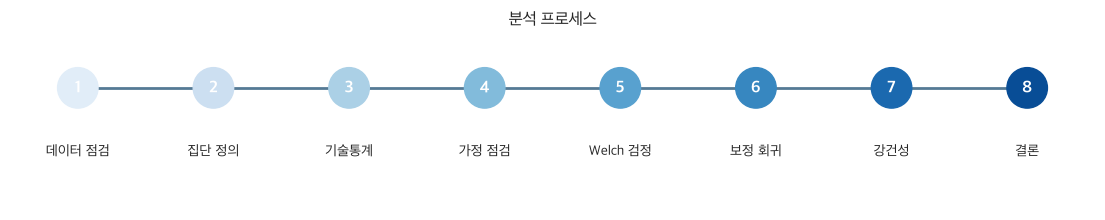

In [1]:
# 1. 환경 설정 — 패키지 버전과 전체 분석 순서를 시각화합니다.
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import scipy
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['axes.unicode_minus'] = False
available_fonts = {item.name for item in font_manager.fontManager.ttflist}
for font in ['Apple SD Gothic Neo', 'Malgun Gothic', 'NanumGothic', 'DejaVu Sans']:
    if font in available_fonts:
        plt.rcParams['font.family'] = font
        break

versions = pd.DataFrame({
    '도구': ['Python', 'pandas', 'NumPy', 'SciPy', 'Seaborn'],
    '버전': [platform.python_version(), pd.__version__, np.__version__, scipy.__version__, sns.__version__]
})
display(versions)

steps = ['데이터 점검', '집단 정의', '기술통계', '가정 점검', 'Welch 검정', '보정 회귀', '강건성', '결론']
fig, ax = plt.subplots(figsize=(14, 2.3))
colors = sns.color_palette('Blues', len(steps))
ax.plot(range(len(steps)), [0] * len(steps), color='#557A95', linewidth=2, zorder=0)
ax.scatter(range(len(steps)), [0] * len(steps), s=850, color=colors, zorder=1)
for i, step in enumerate(steps):
    ax.text(i, 0, str(i + 1), ha='center', va='center', color='white', weight='bold')
    ax.text(i, -0.18, step, ha='center', va='top', fontsize=10)
ax.set(xlim=(-0.5, len(steps)-0.5), ylim=(-0.4, .18), title='분석 프로세스')
ax.axis('off')
plt.show()

,지표,값
0,전체 행,32561
1,전체 열,15
2,완전 중복 행,24
3,education-num 결측,0
4,marital-status 결측,0
5,age 결측,0
6,sex 결측,0


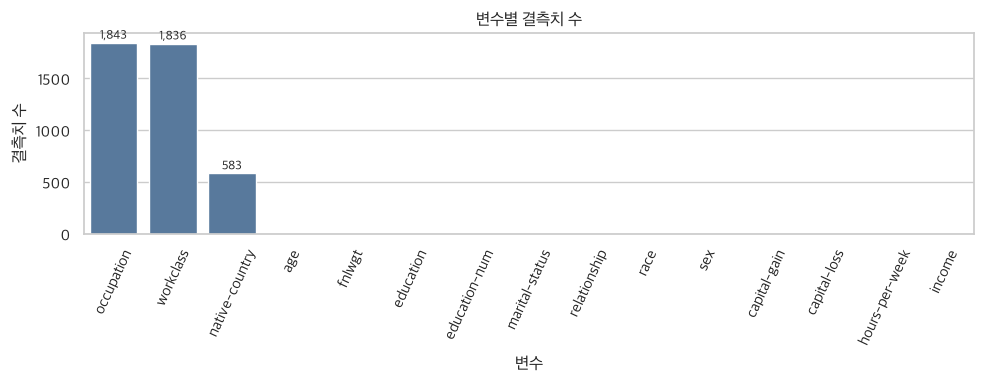

In [2]:
# 2. Adult 데이터 로딩 및 품질 점검
COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]
candidates = [Path('adult.data'), Path.cwd() / 'adult.data', Path.cwd().parent / 'adult.data']
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('adult.data를 찾을 수 없습니다. 노트북과 같은 폴더에 두세요.')

raw = pd.read_csv(data_path, header=None, names=COLUMNS, skipinitialspace=True, na_values=['?', ' ?'])
for column in raw.select_dtypes(include=['object', 'string']).columns:
    raw[column] = raw[column].str.strip()
raw['income'] = raw['income'].str.removesuffix('.')

quality = pd.DataFrame({
    '지표': ['전체 행', '전체 열', '완전 중복 행', 'education-num 결측', 'marital-status 결측', 'age 결측', 'sex 결측'],
    '값': [len(raw), raw.shape[1], int(raw.duplicated().sum()), int(raw['education-num'].isna().sum()),
           int(raw['marital-status'].isna().sum()), int(raw['age'].isna().sum()), int(raw['sex'].isna().sum())]
})
display(quality)

missing = raw.isna().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values, color='#4C78A8', ax=ax)
ax.set(title='변수별 결측치 수', xlabel='변수', ylabel='결측치 수')
ax.tick_params(axis='x', rotation=65)
for i, value in enumerate(missing.values):
    if value > 0:
        ax.text(i, value, f'{value:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

,marriage_experience,marital-status,표본수
0,결혼 경험 없음,Never-married,10667
1,결혼 경험 있음,Divorced,4441
2,결혼 경험 있음,Married-AF-spouse,23
3,결혼 경험 있음,Married-civ-spouse,14970
4,결혼 경험 있음,Married-spouse-absent,418
5,결혼 경험 있음,Separated,1025
6,결혼 경험 있음,Widowed,993


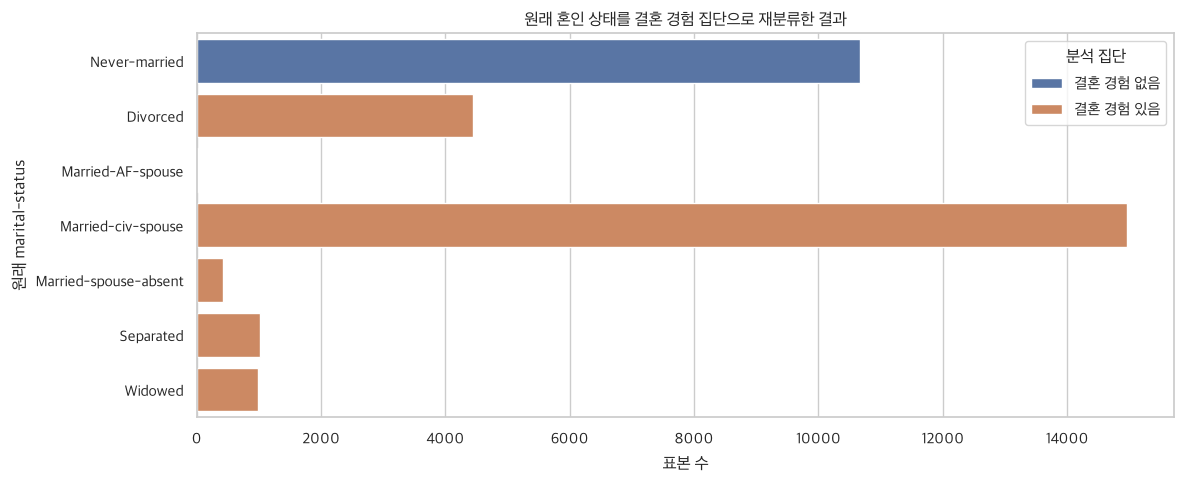

In [3]:
# 3. 결혼 경험 집단 및 연령 범위 정의
# 연령 필터: None은 제한 없음. 예시는 MIN_AGE=30, MAX_AGE=54
MIN_AGE = None
MAX_AGE = None

EVER_MARRIED = {
    'Married-civ-spouse', 'Married-AF-spouse', 'Married-spouse-absent',
    'Divorced', 'Separated', 'Widowed'
}
NEVER_MARRIED = {'Never-married'}
valid_statuses = EVER_MARRIED | NEVER_MARRIED
selected = raw.drop_duplicates().loc[lambda df: df['marital-status'].isin(valid_statuses)].copy()
if MIN_AGE is not None:
    selected = selected.loc[selected['age'] >= MIN_AGE].copy()
if MAX_AGE is not None:
    selected = selected.loc[selected['age'] <= MAX_AGE].copy()

selected['marriage_experience'] = np.where(
    selected['marital-status'].isin(EVER_MARRIED), '결혼 경험 있음', '결혼 경험 없음'
)
selected['marriage_experience'] = pd.Categorical(
    selected['marriage_experience'], categories=['결혼 경험 없음', '결혼 경험 있음'], ordered=True
)
analysis_df = selected.dropna(subset=['education-num', 'age', 'sex', 'marriage_experience']).copy()
analysis_df['ever_married'] = (analysis_df['marriage_experience'] == '결혼 경험 있음').astype(int)

status_summary = (analysis_df.groupby(['marriage_experience', 'marital-status'], observed=True)
                  .size().rename('표본수').reset_index())
display(status_summary)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=status_summary, y='marital-status', x='표본수', hue='marriage_experience', dodge=False, ax=ax)
ax.set(title='원래 혼인 상태를 결혼 경험 집단으로 재분류한 결과', xlabel='표본 수', ylabel='원래 marital-status')
ax.legend(title='분석 집단')
plt.tight_layout()
plt.show()

,marriage_experience,표본수,평균,중앙값,표준편차
0,결혼 경험 없음,"10,667",9.965,10.0,2.384
1,결혼 경험 있음,"21,870",10.139,10.0,2.657


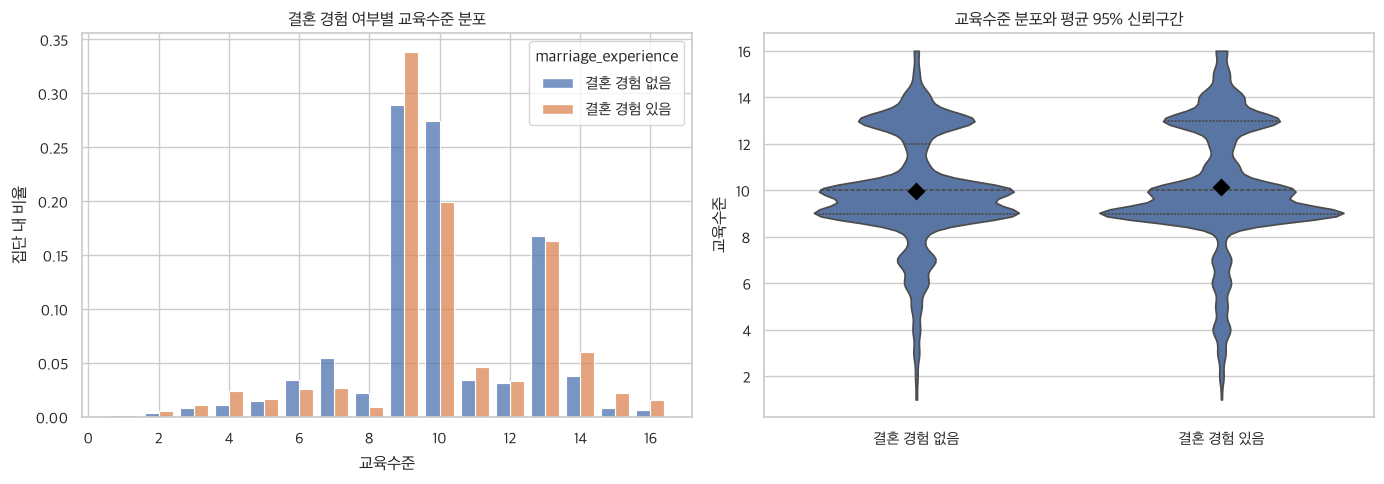

In [4]:
# 4. 집단별 교육수준 기술통계와 분포 확인
sample_summary = (analysis_df.groupby('marriage_experience', observed=False)['education-num']
                  .agg(표본수='size', 평균='mean', 중앙값='median', 표준편차='std')
                  .reset_index())
summary_display = sample_summary.copy()
summary_display['표본수'] = summary_display['표본수'].map(lambda x: f'{x:,.0f}')
for column, digits in [('평균', 3), ('중앙값', 1), ('표준편차', 3)]:
    summary_display[column] = summary_display[column].map(lambda x, d=digits: f'{x:.{d}f}')
display(summary_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=analysis_df, x='education-num', hue='marriage_experience', discrete=True,
             stat='probability', common_norm=False, multiple='dodge', shrink=.8, ax=axes[0])
axes[0].set(title='결혼 경험 여부별 교육수준 분포', xlabel='교육수준', ylabel='집단 내 비율')
sns.violinplot(data=analysis_df, x='marriage_experience', y='education-num', inner='quartile', cut=0, ax=axes[1])
sns.pointplot(data=analysis_df, x='marriage_experience', y='education-num', color='black',
              markers='D', linestyles='none', errorbar=('ci', 95), ax=axes[1])
axes[1].set(title='교육수준 분포와 평균 95% 신뢰구간', xlabel='', ylabel='교육수준')
plt.tight_layout()
plt.show()

,점검,값
0,결혼 경험 있음 표본 수,"21,870"
1,결혼 경험 없음 표본 수,"10,667"
2,결혼 경험 있음 분산,7.05702
3,결혼 경험 없음 분산,5.68374
4,Levene 통계량,138.96
5,Levene p-value,5.22129e-32


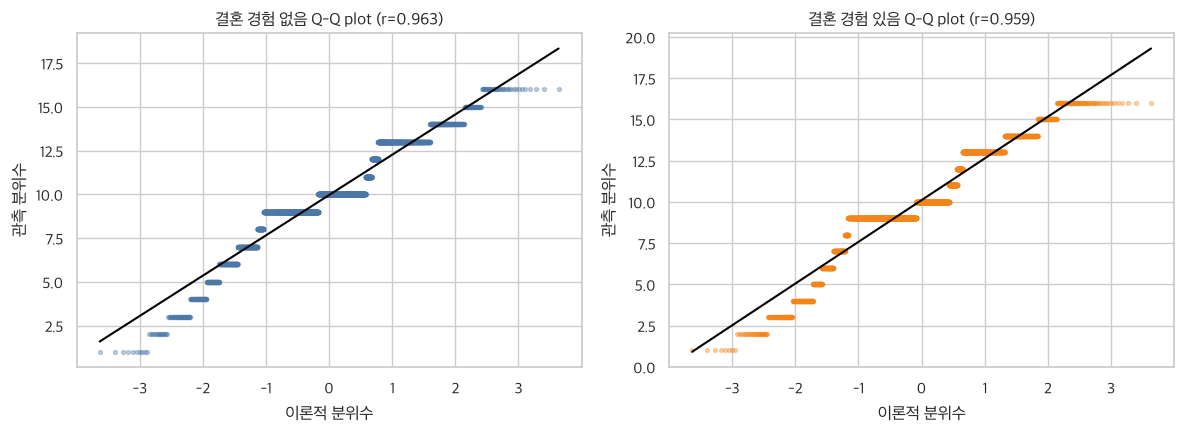

In [5]:
# 5. 분산과 분포 점검 — 등분산을 가정하지 않는 Welch 검정을 선택합니다.
never = analysis_df.loc[analysis_df['ever_married'] == 0, 'education-num'].astype(float).to_numpy()
ever = analysis_df.loc[analysis_df['ever_married'] == 1, 'education-num'].astype(float).to_numpy()
levene_stat, levene_p = stats.levene(ever, never, center='median')
assumptions = pd.DataFrame({
    '점검': ['결혼 경험 있음 표본 수', '결혼 경험 없음 표본 수', '결혼 경험 있음 분산',
           '결혼 경험 없음 분산', 'Levene 통계량', 'Levene p-value'],
    '값': [len(ever), len(never), ever.var(ddof=1), never.var(ddof=1), levene_stat, levene_p]
})
assumptions_display = assumptions.copy()
assumptions_display['값'] = assumptions_display['값'].map(lambda x: f'{x:,.6g}')
display(assumptions_display)

rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for values, title, ax, color in [
    (never, '결혼 경험 없음 Q-Q plot', axes[0], '#4C78A8'),
    (ever, '결혼 경험 있음 Q-Q plot', axes[1], '#F58518')
]:
    sample = rng.choice(values, size=min(5000, len(values)), replace=False)
    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
    ax.scatter(osm, osr, s=8, alpha=.35, color=color)
    ax.plot(osm, slope*np.asarray(osm)+intercept, color='black', linewidth=1.5)
    ax.set(title=f'{title} (r={r:.3f})', xlabel='이론적 분위수', ylabel='관측 분위수')
plt.tight_layout()
plt.show()

,결혼 경험 있음 평균,결혼 경험 없음 평균,평균 차이(있음-없음),95% CI 하한,95% CI 상한,Welch t,자유도,p-value,Hedges g,판정
0,10.1389,9.96475,0.174161,0.11683,0.231491,5.95438,23324.2,2.64798e-09,0.0677554,귀무가설 기각


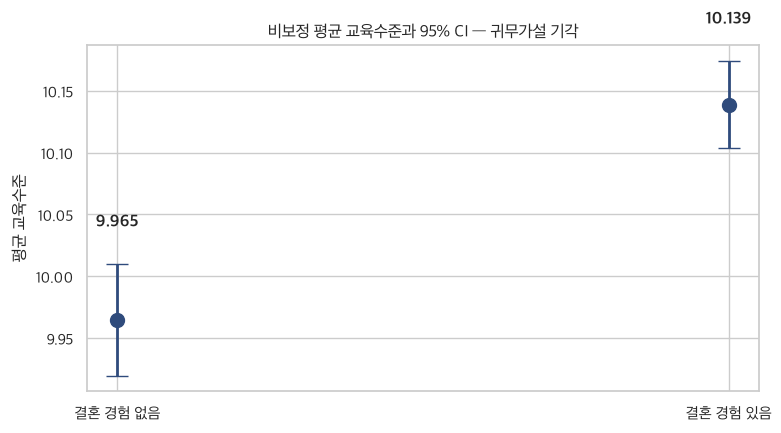

In [6]:
# 6. 주 분석: 양측 Welch 독립표본 t-test
ALPHA = 0.05
t_stat, p_value = stats.ttest_ind(ever, never, equal_var=False, alternative='two-sided')
raw_diff = ever.mean() - never.mean()
var_e, var_n = ever.var(ddof=1), never.var(ddof=1)
raw_se = np.sqrt(var_e/len(ever) + var_n/len(never))
welch_df = (var_e/len(ever) + var_n/len(never))**2 / (
    (var_e/len(ever))**2/(len(ever)-1) + (var_n/len(never))**2/(len(never)-1)
)
critical = stats.t.ppf(1-ALPHA/2, df=welch_df)
raw_ci_low, raw_ci_high = raw_diff-critical*raw_se, raw_diff+critical*raw_se
pooled_sd = np.sqrt(((len(ever)-1)*var_e + (len(never)-1)*var_n)/(len(ever)+len(never)-2))
hedges_correction = 1 - 3/(4*(len(ever)+len(never))-9)
hedges_g = hedges_correction * raw_diff/pooled_sd
welch_decision = '귀무가설 기각' if p_value < ALPHA else '귀무가설 기각 못함'

welch_result = pd.DataFrame({
    '결혼 경험 있음 평균': [ever.mean()], '결혼 경험 없음 평균': [never.mean()],
    '평균 차이(있음-없음)': [raw_diff], '95% CI 하한': [raw_ci_low], '95% CI 상한': [raw_ci_high],
    'Welch t': [t_stat], '자유도': [welch_df], 'p-value': [p_value],
    'Hedges g': [hedges_g], '판정': [welch_decision]
})
welch_display = welch_result.copy()
for column in welch_display.columns:
    if column != '판정':
        welch_display[column] = welch_display[column].map(lambda x: f'{x:.6g}')
display(welch_display)

means = np.array([never.mean(), ever.mean()])
mean_ci = stats.norm.ppf(.975) * np.array([never.std(ddof=1)/np.sqrt(len(never)), ever.std(ddof=1)/np.sqrt(len(ever))])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(['결혼 경험 없음', '결혼 경험 있음'], means, yerr=mean_ci, fmt='o',
            markersize=10, capsize=8, linewidth=2, color='#2F4B7C')
for x_pos, mean, margin in zip(range(2), means, mean_ci):
    ax.text(x_pos, mean+margin+.03, f'{mean:.3f}', ha='center', weight='bold')
ax.set(title=f'비보정 평균 교육수준과 95% CI — {welch_decision}', xlabel='', ylabel='평균 교육수준')
plt.tight_layout()
plt.show()

,변수,계수,HC3 표준오차,t,p-value,95% CI 하한,95% CI 상한
0,절편,10.722,0.0408845,262.252,0,10.6419,10.8022
1,결혼 경험 있음,-0.36478,0.0383578,-9.50992,2.03453e-21,-0.439962,-0.289597
2,나이(표준화),0.407945,0.0192959,21.1416,1.51992e-98,0.370125,0.445766
3,나이 제곱,-0.401096,0.0150859,-26.5874,4.22298e-154,-0.430665,-0.371527
4,남성,0.00908349,0.0290175,0.313035,0.754256,-0.0477918,0.0659588


,결혼 경험 없음 보정 평균,결혼 경험 있음 보정 평균,보정 평균 차이,95% CI 하한,95% CI 상한,p-value,판정
0,10.327,9.96222,-0.36478,-0.439962,-0.289597,2.03453e-21,귀무가설 기각


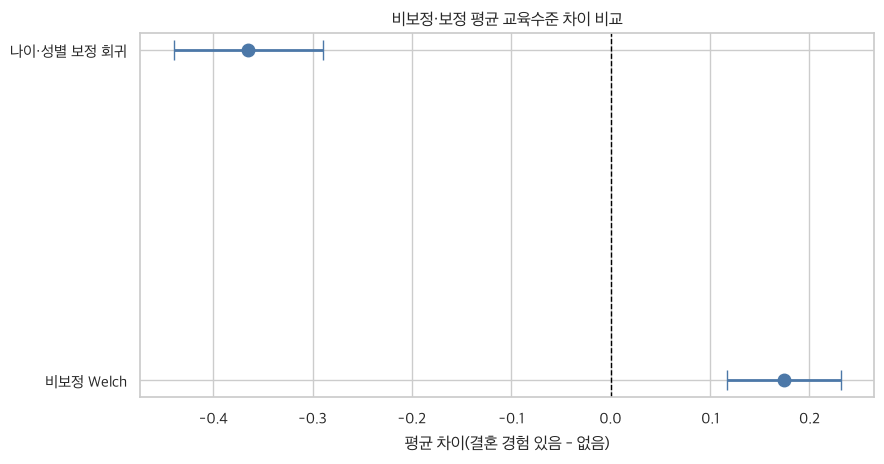

In [7]:
# 7. 보정 분석: 나이, 나이 제곱, 성별을 통제한 OLS 회귀(HC3 강건 표준오차)
# 같은 대상자의 나이·성별은 그대로 둔 채 결혼 경험 값만 0/1로 바꾸어 표준화 평균을 계산합니다.
y = analysis_df['education-num'].to_numpy(dtype=float)
age = analysis_df['age'].to_numpy(dtype=float)
age_z = (age-age.mean())/age.std(ddof=0)
male = analysis_df['sex'].eq('Male').to_numpy(dtype=float)
group = analysis_df['ever_married'].to_numpy(dtype=float)
X = np.column_stack([np.ones(len(y)), group, age_z, age_z**2, male])
terms = ['절편', '결혼 경험 있음', '나이(표준화)', '나이 제곱', '남성']

beta = np.linalg.lstsq(X, y, rcond=None)[0]
residual = y-X@beta
xtx_inv = np.linalg.pinv(X.T@X)
leverage = np.sum((X@xtx_inv)*X, axis=1)
hc3_weight = (residual/np.clip(1-leverage, 1e-8, None))**2
hc3_cov = xtx_inv @ (X.T @ (hc3_weight[:, None]*X)) @ xtx_inv
robust_se = np.sqrt(np.diag(hc3_cov))
df_resid = len(y)-X.shape[1]
test_stat = beta/robust_se
reg_p_values = 2*stats.t.sf(np.abs(test_stat), df=df_resid)
reg_critical = stats.t.ppf(1-ALPHA/2, df=df_resid)
reg_ci_low = beta-reg_critical*robust_se
reg_ci_high = beta+reg_critical*robust_se

regression_result = pd.DataFrame({
    '변수': terms, '계수': beta, 'HC3 표준오차': robust_se, 't': test_stat,
    'p-value': reg_p_values, '95% CI 하한': reg_ci_low, '95% CI 상한': reg_ci_high
})
regression_display = regression_result.copy()
for column in regression_display.columns[1:]:
    regression_display[column] = regression_display[column].map(lambda x: f'{x:.6g}')
display(regression_display)

X_never, X_ever = X.copy(), X.copy()
X_never[:, 1], X_ever[:, 1] = 0, 1
adjusted_mean_never = float((X_never@beta).mean())
adjusted_mean_ever = float((X_ever@beta).mean())
adjusted_diff = float(beta[1])
adjusted_se = float(robust_se[1])
adjusted_ci_low, adjusted_ci_high = float(reg_ci_low[1]), float(reg_ci_high[1])
adjusted_p = float(reg_p_values[1])
adjusted_decision = '귀무가설 기각' if adjusted_p < ALPHA else '귀무가설 기각 못함'

adjusted_summary = pd.DataFrame({
    '결혼 경험 없음 보정 평균': [adjusted_mean_never], '결혼 경험 있음 보정 평균': [adjusted_mean_ever],
    '보정 평균 차이': [adjusted_diff], '95% CI 하한': [adjusted_ci_low],
    '95% CI 상한': [adjusted_ci_high], 'p-value': [adjusted_p], '판정': [adjusted_decision]
})
adjusted_display = adjusted_summary.copy()
for column in adjusted_display.columns:
    if column != '판정':
        adjusted_display[column] = adjusted_display[column].map(lambda x: f'{x:.6g}')
display(adjusted_display)

comparison = pd.DataFrame({
    '분석': ['비보정 Welch', '나이·성별 보정 회귀'],
    '평균 차이': [raw_diff, adjusted_diff],
    'CI 하한': [raw_ci_low, adjusted_ci_low], 'CI 상한': [raw_ci_high, adjusted_ci_high]
})
fig, ax = plt.subplots(figsize=(9, 4.8))
xerr = np.vstack([comparison['평균 차이']-comparison['CI 하한'], comparison['CI 상한']-comparison['평균 차이']])
ax.errorbar(comparison['평균 차이'], comparison['분석'], xerr=xerr, fmt='o',
            markersize=9, capsize=7, linewidth=2, color='#4C78A8')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set(title='비보정·보정 평균 교육수준 차이 비교', xlabel='평균 차이(결혼 경험 있음 - 없음)', ylabel='')
plt.tight_layout()
plt.show()

,방법,결과,0.05 기준
0,Welch t-test,p=2.648e-09,귀무가설 기각
1,평균 차이 부트스트랩,"95% CI [0.115, 0.232]",0 미포함
2,Mann–Whitney U test,p=9.743e-07,귀무가설 기각


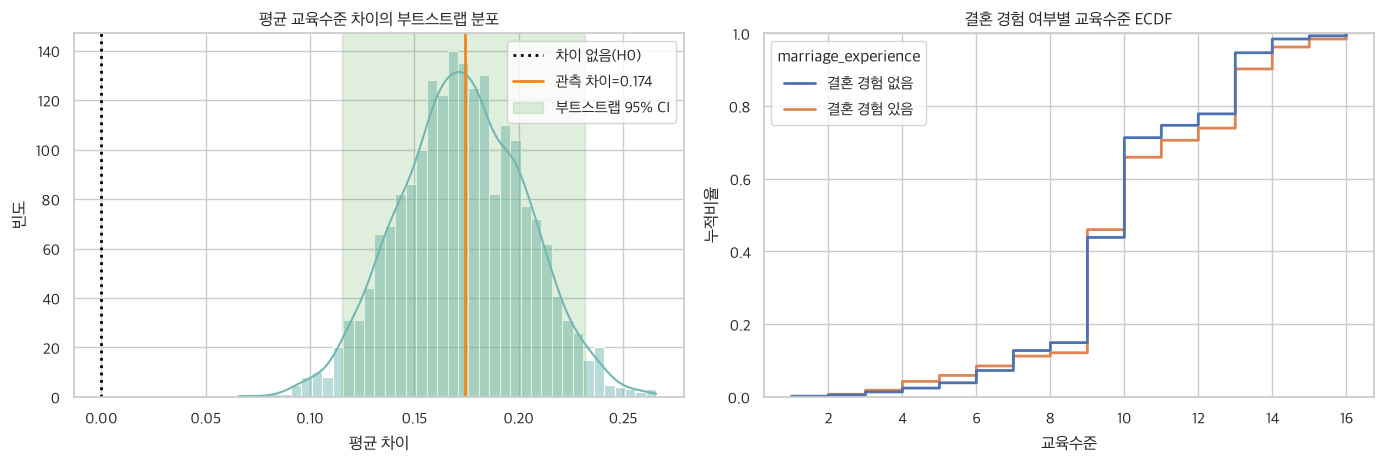

In [8]:
# 8. 강건성 검토: 부트스트랩 평균 차이와 Mann–Whitney U test
BOOTSTRAPS = 2000
rng = np.random.default_rng(42)
bootstrap_differences = np.empty(BOOTSTRAPS)
for i in range(BOOTSTRAPS):
    bootstrap_differences[i] = (
        rng.choice(ever, size=len(ever), replace=True).mean()
        - rng.choice(never, size=len(never), replace=True).mean()
    )
boot_low, boot_high = np.quantile(bootstrap_differences, [.025, .975])
u_stat, u_p = stats.mannwhitneyu(ever, never, alternative='two-sided')
robustness = pd.DataFrame({
    '방법': ['Welch t-test', '평균 차이 부트스트랩', 'Mann–Whitney U test'],
    '결과': [f'p={p_value:.3e}', f'95% CI [{boot_low:.3f}, {boot_high:.3f}]', f'p={u_p:.3e}'],
    '0.05 기준': [welch_decision, '0 미포함' if not boot_low <= 0 <= boot_high else '0 포함',
                  '귀무가설 기각' if u_p < ALPHA else '귀무가설 기각 못함']
})
display(robustness)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(bootstrap_differences, bins=40, kde=True, color='#72B7B2', ax=axes[0])
axes[0].axvline(0, color='black', linestyle=':', linewidth=2, label='차이 없음(H0)')
axes[0].axvline(raw_diff, color='#F58518', linewidth=2, label=f'관측 차이={raw_diff:.3f}')
axes[0].axvspan(boot_low, boot_high, color='#54A24B', alpha=.18, label='부트스트랩 95% CI')
axes[0].set(title='평균 교육수준 차이의 부트스트랩 분포', xlabel='평균 차이', ylabel='빈도')
axes[0].legend()
sns.ecdfplot(data=analysis_df, x='education-num', hue='marriage_experience', linewidth=2, ax=axes[1])
axes[1].set(title='결혼 경험 여부별 교육수준 ECDF', xlabel='교육수준', ylabel='누적비율')
plt.tight_layout()
plt.show()

,분석,평균 차이,95% CI,p-value,판정
0,Welch t-test(비보정),0.1742,"[0.117, 0.231]",2.648e-09,귀무가설 기각
1,OLS 회귀(나이·성별 보정),-0.3648,"[-0.440, -0.290]",2.035e-21,귀무가설 기각


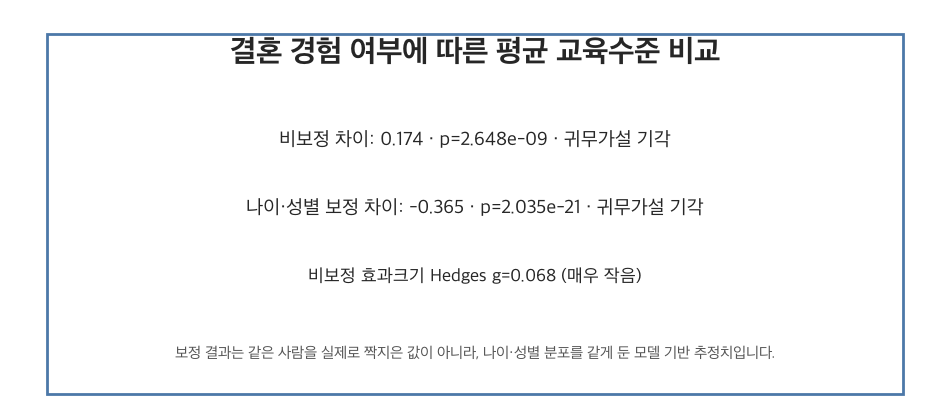

In [9]:
# 9. 최종 결론 대시보드 — 비보정 결과와 보정 결과를 함께 해석합니다.
effect_magnitude = ('매우 작음' if abs(hedges_g) < .2 else '작음' if abs(hedges_g) < .5
                    else '중간' if abs(hedges_g) < .8 else '큼')
final_summary = pd.DataFrame({
    '분석': ['Welch t-test(비보정)', 'OLS 회귀(나이·성별 보정)'],
    '평균 차이': [raw_diff, adjusted_diff],
    '95% CI': [f'[{raw_ci_low:.3f}, {raw_ci_high:.3f}]', f'[{adjusted_ci_low:.3f}, {adjusted_ci_high:.3f}]'],
    'p-value': [p_value, adjusted_p],
    '판정': [welch_decision, adjusted_decision]
})
final_display = final_summary.copy()
final_display['평균 차이'] = final_display['평균 차이'].map(lambda x: f'{x:.4f}')
final_display['p-value'] = final_display['p-value'].map(lambda x: f'{x:.3e}')
display(final_display)

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.axis('off')
ax.text(.5, .87, '결혼 경험 여부에 따른 평균 교육수준 비교', ha='center', fontsize=22, weight='bold', transform=ax.transAxes)
ax.text(.5, .66, f'비보정 차이: {raw_diff:.3f} · p={p_value:.3e} · {welch_decision}',
        ha='center', fontsize=14, transform=ax.transAxes)
ax.text(.5, .49, f'나이·성별 보정 차이: {adjusted_diff:.3f} · p={adjusted_p:.3e} · {adjusted_decision}',
        ha='center', fontsize=14, transform=ax.transAxes)
ax.text(.5, .32, f'비보정 효과크기 Hedges g={hedges_g:.3f} ({effect_magnitude})',
        ha='center', fontsize=13, transform=ax.transAxes)
ax.text(.5, .13, '보정 결과는 같은 사람을 실제로 짝지은 값이 아니라, 나이·성별 분포를 같게 둔 모델 기반 추정치입니다.',
        ha='center', fontsize=11, color='#555555', transform=ax.transAxes)
ax.add_patch(plt.Rectangle((.04, .04), .92, .9, fill=False, linewidth=2, edgecolor='#4C78A8', transform=ax.transAxes))
plt.show()

## 10. End-to-End 파이프라인 — 데이터 처리·Plotly·ML Pipeline·자동 보고서

결혼 경험 통계 분석과 같은 주제로 ML 분석을 확장한다. 아래 모듈은 Pandas·Polars 비교, 분할 전 중복 제거, 분할 후 Pipeline 내부 결측치 처리, 분위수·상관분석, Plotly HTML, 결혼 경험 예측, 정확도·F1, 모델 저장 및 `report.md` 생성을 수행한다. `marital-status`와 `relationship`은 타깃 누수를 방지하기 위해 모델 입력에서 제외한다.

In [10]:
# 10. End-to-End 분석 파이프라인 실행
import importlib
import day2_pipeline

importlib.reload(day2_pipeline)
pipeline_result = day2_pipeline.run_pipeline(data_path='adult.data', output_dir='artifacts')
display(pipeline_result)

,라이브러리,행,열,로딩 시간(초),추정 메모리(MB)
0,Pandas,32561,15,0.0171,19.7770
1,Polars,32561,15,0.0459,3.0719


,지표,원본,분할 전 중복 제거 후,처리 위치 및 방법
0,전체 행,32561,32537,분할 전 완전 중복 제거
1,전체 결측치,4262,4261,분할 후 Pipeline에서 대체
2,완전 중복 행,24,0,분할 전 24건 제거
3,분석 핵심 변수 결측치,0,0,원래 결측치 없음—별도 대체 불필요


,표본수,평균,표준편차,최솟값,1사분위수,중앙값,3사분위수,최댓값
변수,,,,,,,,
age,32537.0,38.586,13.638,17.0,28.0,37.0,48.0,90.0
fnlwgt,32537.0,189780.849,105556.471,12285.0,117827.0,178356.0,236993.0,1484705.0
education-num,32537.0,10.082,2.572,1.0,9.0,10.0,12.0,16.0
capital-gain,32537.0,1078.444,7387.957,0.0,0.0,0.0,0.0,99999.0
capital-loss,32537.0,87.368,403.102,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32537.0,40.440,12.347,1.0,40.0,40.0,45.0,99.0


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000,-0.076,0.036,0.078,0.058,0.069
fnlwgt,-0.076,1.000,-0.043,0.000,-0.010,-0.019
education-num,0.036,-0.043,1.000,0.123,0.080,0.148
capital-gain,0.078,0.000,0.123,1.000,-0.032,0.078
capital-loss,0.058,-0.010,0.080,-0.032,1.000,0.054
hours-per-week,0.069,-0.019,0.148,0.078,0.054,1.000


,결혼 경험 없음 표본수,결혼 경험 있음 표본수,결혼 경험 없음 평균,결혼 경험 있음 평균,평균 차이(있음-없음),95% CI 하한,95% CI 상한,Welch t,p-value,Hedges g,판정
0,10667,21870,9.9648,10.1389,0.1742,0.1168,0.2315,5.9544,0.0,0.0678,귀무가설 기각


,정확도,F1
0,0.8228,0.8696


PipelineResult(rows_before=32561, rows_after=32537, duplicates_removed=24, missing_before_split=4261, missing_after_preprocessing=0, accuracy=0.8228334357713584, f1=0.8696438665912946, output_dir=PosixPath('artifacts'), report_path=PosixPath('artifacts/report.md'), model_path=PosixPath('artifacts/marriage_experience_pipeline.joblib'), plotly_path=PosixPath('artifacts/plotly_education_by_marriage.html'), ttest_path=PosixPath('artifacts/marriage_ttest_results.csv'))

### 해석 제한

표본이 매우 크면 작은 차이도 통계적으로 유의할 수 있으므로 p-value와 함께 평균 차이, 신뢰구간, 효과크기를 해석한다. 또한 이 분석은 1994년 미국 Adult 데이터의 단면적 연관성이므로 결혼 경험의 인과효과로 표현하지 않는다.